# Project Name: Bangalore Dining Dynamics: Analyzing Ratings, Cost, and Popularity
## Project By: Stephen Argho Das
## Data Source: Kaggle [DataSet Source](https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants)

### Section 1: All Imports for The Project

In [1]:
import kagglehub
import shutil
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

d:\Spring Sem 26\Programming with Python\Final\Project_Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Section 2: Data Loading

In [2]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "Data")
os.makedirs(DATA_DIR, exist_ok=True)

def download_kaggle_dataset(dataset_name, overwrite=False):
    # Download to kagglehub cache
    download_path = kagglehub.dataset_download(dataset_name)

    saved_files = []
    for item in os.listdir(download_path):
        src = os.path.join(download_path, item)
        dst = os.path.join(DATA_DIR, item)

        if os.path.exists(dst) and not overwrite:
            continue

        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

        saved_files.append(dst)

    # Only proceed if something was saved
    if saved_files:
        print(f"Dataset saved successfully to: {DATA_DIR}")
        # Try reading first CSV found
        for file in saved_files:
            if file.endswith(".csv"):
                df = pd.read_csv(file)
                print("\nColumns:", list(df.columns))
                return df
    else:
        print("No new files saved (already exists).")

# Download dataset
data= download_kaggle_dataset("himanshupoddar/zomato-bangalore-restaurants")


Dataset saved successfully to: d:\Spring Sem 26\Programming with Python\Final\Project_Final\Data

Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


### Section 3 : Understanding Data

In [5]:
df= pd.read_csv(os.path.join(DATA_DIR, "zomato.csv"), encoding="latin-1")
print("Shape before cleaning", df.shape)
df.head(3)
print("Data types: ", df.dtypes)
print("Missing values: ", df.isnull().sum())
print("Summary statistics: ", df.describe())

# Insight from this step:
# 1. 'dish_liked' has 28,078 missing values (over 50%), making it unreliable for core analysis.
# 2. 'rate' and 'approx_cost(for two people)' are strings instead of numbers, requiring conversion.
# 3. 'votes' has a massive max value (16,832) compared to its 75th percentile (198), indicating heavy outliers.

Shape before cleaning (51717, 17)
Data types:  url                              str
address                          str
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
phone                            str
location                         str
rest_type                        str
dish_liked                       str
cuisines                         str
approx_cost(for two people)      str
reviews_list                     str
menu_item                        str
listed_in(type)                  str
listed_in(city)                  str
dtype: object
Missing values:  url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           12

### Section 4: Data Cleaning & Preparation

In [6]:
# Cleaning Step 1: Drop irrelevant and heavily missing columns
df.drop(['url', 'address', 'phone', 'dish_liked', 'reviews_list', 'menu_item'], axis=1, inplace=True)
# Cleaning Step 2: Clean and convert the 'rate' column
def clean_rate(val):
    if pd.isna(val) or val == 'NEW' or val == '-':
        return np.nan
    return float(str(val).split('/')[0].strip())

df['rate'] = df['rate'].apply(clean_rate)
# Cleaning Step 3: Clean and convert 'approx_cost(for two people)'
df.rename(columns={'approx_cost(for two people)': 'cost_for_two', 'listed_in(type)': 'listing_type'}, inplace=True)

def clean_cost(val):
    if pd.isna(val):
        return np.nan
    return float(str(val).replace(',', ''))

df['cost_for_two'] = df['cost_for_two'].apply(clean_cost)
# Cleaning Step 4: Drop missing values in critical analytical columns
df.dropna(subset=['rate', 'cost_for_two', 'location', 'rest_type', 'cuisines'], inplace=True)

print("Shape after cleaning:", df.shape)


Shape after cleaning: (41263, 11)


### Section 5: Feature Engineering

In [ ]:
#Feature 1: cost_per_person
df['cost_per_person'] = df['cost_for_two'] / 2
# Feature 2: cuisine_count
df['cuisine_count'] = df['cuisines'].apply(lambda x: len(str(x).split(',')))

# Feature 3: popularity_tier (Categorical derived feature)
conditions = [
    (df['votes'] < 50),
    (df['votes'] >= 50) & (df['votes'] < 500),
    (df['votes'] >= 500)
]
choices = ['Low', 'Medium', 'High']
df['popularity_tier'] = np.select(conditions, choices, default='Unknown')

df[['name', 'cost_per_person', 'cuisine_count', 'popularity_tier']].head()

,name,cost_per_person,cuisine_count,popularity_tier
0,Jalsa,400.0,3,High
1,Spice Elephant,400.0,3,High
2,San Churro Cafe,400.0,3,High
3,Addhuri Udupi Bhojana,150.0,2,Medium
4,Grand Village,300.0,2,Medium


### Section 6: Numpy-Based Custom Computation

In [9]:
# Logic: A restaurant provides high value if its rating is high AND its cost is low.

# Convert Pandas Series to NumPy Arrays
rate_arr = df['rate'].to_numpy()
cost_arr = df['cost_per_person'].to_numpy()

# Calculate NumPy statistics
mean_rate, std_rate = np.mean(rate_arr), np.std(rate_arr)
mean_cost, std_cost = np.mean(cost_arr), np.std(cost_arr)

# Calculate Z-scores using NumPy
z_rate = (rate_arr - mean_rate) / std_rate
z_cost = (cost_arr - mean_cost) / std_cost

# Final NumPy computation: Value Score
df['value_score'] = z_rate - z_cost

print("Top 5 Restaurants by Value Score:")
df.sort_values(by='value_score', ascending=False).head(5)

Top 5 Restaurants by Value Score:


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two,listing_type,listed_in(city),cost_per_person,cuisine_count,popularity_tier,value_score
3338,Brahmin's Coffee Bar,No,No,4.8,2679,Basavanagudi,Quick Bites,South Indian,100.0,Dine-out,Basavanagudi,50.0,1,High,3.579377
46445,CTR,Yes,No,4.8,4421,Malleshwaram,Quick Bites,South Indian,150.0,Delivery,Rajajinagar,75.0,1,High,3.471835
46973,CTR,Yes,No,4.8,4421,Malleshwaram,Quick Bites,South Indian,150.0,Dine-out,Rajajinagar,75.0,1,High,3.471835
40068,O.G. Variar & Sons,No,No,4.8,1156,Rajajinagar,Bakery,"Bakery, Desserts",200.0,Desserts,Malleshwaram,100.0,2,High,3.364294
46630,O.G. Variar & Sons,No,No,4.8,1161,Rajajinagar,Bakery,"Bakery, Desserts",200.0,Desserts,Rajajinagar,100.0,2,High,3.364294


### Helper Section for Visualization: Importing and Loading Fonts for Charts

In [10]:
font_dir = './Fonts/'
loaded_fonts = {}

for font_file in os.listdir(font_dir):
    if font_file.endswith('.ttf'):
        font_path = os.path.join(font_dir, font_file)

        font_manager.fontManager.addfont(font_path)

        prop = font_manager.FontProperties(fname=font_path)
        font_name = prop.get_name()
        loaded_fonts[font_file] = font_name

print("Successfully loaded the following fonts:")
for file, name in loaded_fonts.items():
    print(f"  • {file} -> Use name: '{name}'")

plt.rcParams['font.family'] = 'Poppins'

print(f"\n✅ Global font is currently set to: {plt.rcParams['font.family']}")

Successfully loaded the following fonts:
  • Epilogue-Light.ttf -> Use name: 'Epilogue'
  • Lato-Regular.ttf -> Use name: 'Lato'
  • Manrope-Light.ttf -> Use name: 'Manrope'
  • OpenSans-Light.ttf -> Use name: 'Open Sans'
  • Poppins-Light.ttf -> Use name: 'Poppins'
  • Questrial-Regular.ttf -> Use name: 'Questrial'

✅ Global font is currently set to: ['Poppins']


### Section 7: Analysis and Visualizations

##### Section 7.1: Subgroup Comparison Plot (Rating vs Type)

Figure saved successfully to: d:\Spring Sem 26\Programming with Python\Final\Project_Final\Figures\Average_Rating_by_Restaurant_Service_Type.png


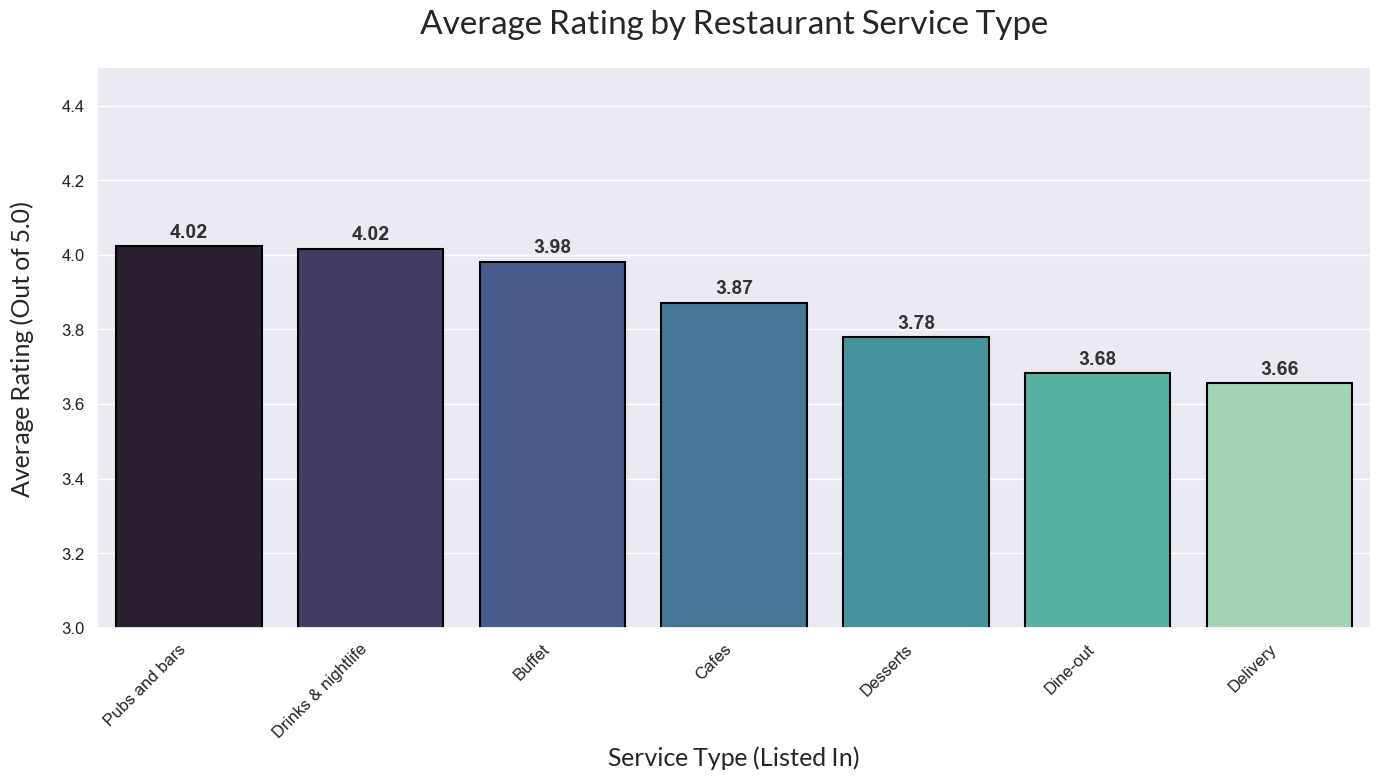

In [23]:
fig_dir = os.path.join(os.getcwd(), 'Figures')
os.makedirs(fig_dir, exist_ok=True)

sns.set_theme(style="darkgrid", font_scale=1.1)

# Group the data
listing_ratings = df.groupby('listing_type')['rate'].mean().reset_index()
listing_ratings = listing_ratings.sort_values(by='rate', ascending=False)

plt.figure(figsize=(14, 8))

# Create the barplot using Seaborn
ax = sns.barplot(
    data=listing_ratings, 
    x='listing_type', 
    y='rate',
    hue='listing_type',
    legend=False, 
    palette='mako',
    edgecolor='black', 
    linewidth=1.5,
)

plt.title('Average Rating by Restaurant Service Type', fontsize=24, fontweight='bold', fontfamily='Lato', pad=25)
plt.xlabel('Service Type (Listed In)', fontsize=18, fontweight='bold', fontfamily='Lato')
plt.ylabel('Average Rating (Out of 5.0)', fontsize=18, fontweight='bold', fontfamily='Lato', labelpad=20)

plt.ylim(3.0, 4.5) 
plt.xticks(rotation=45, ha='right')

# Add floating value labels elegantly
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=14, fontweight='bold', color='#333333')

sns.despine(left=True)
plt.tight_layout()
file_name = 'Average_Rating_by_Restaurant_Service_Type' + '.png'
save_path = os.path.join(fig_dir, file_name)
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
print(f"Figure saved successfully to: {save_path}")
plt.show()

##### Section 7.2: Relationship Analysis Plot (Cost vs Ratings & Votes)

Correlation between Cost and Rating: 0.39
✅ Figure saved successfully to: d:\Spring Sem 26\Programming with Python\Final\Project_Final\Figures\Cost_vs_Ratings_The_Impact_of_Popularity.png


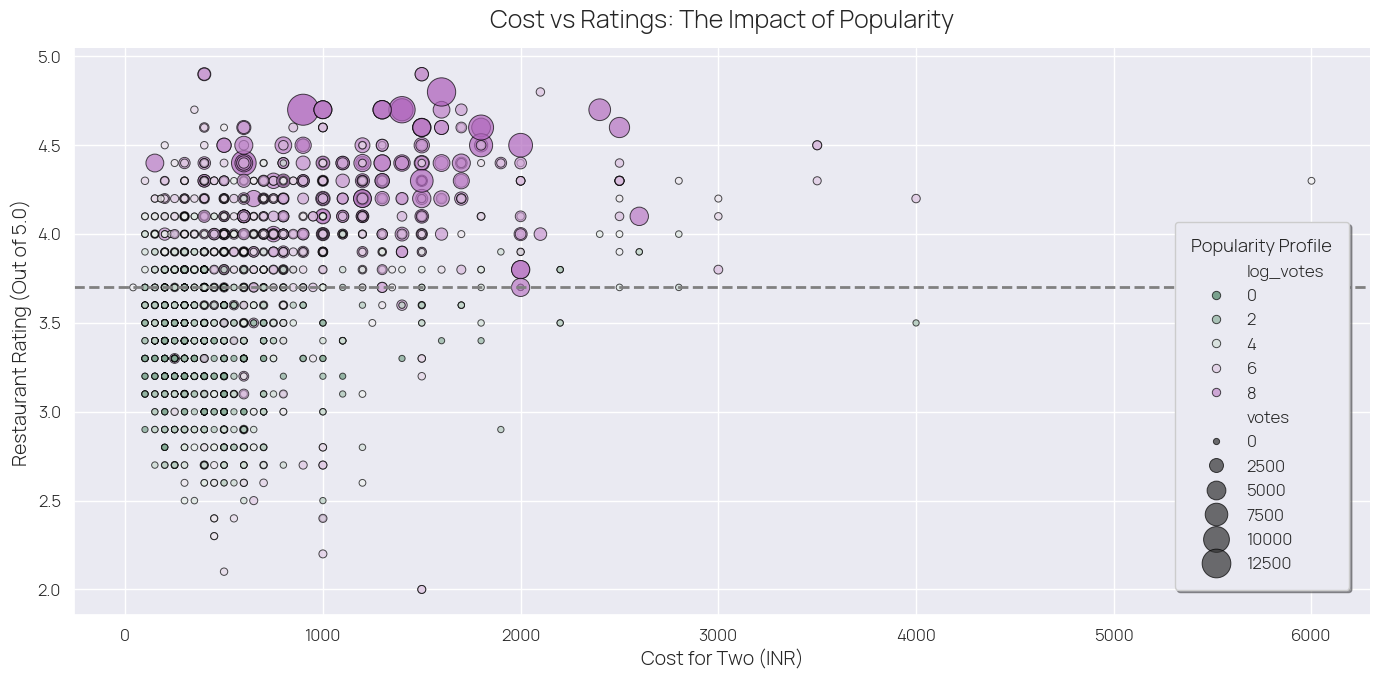

In [46]:
plt.rcParams['font.family'] = 'Manrope'
plt.figure(figsize=(14, 7))

# Calculate correlation coefficient
corr_cost_rate = df['cost_for_two'].corr(df['rate'])
print(f"Correlation between Cost and Rating: {corr_cost_rate:.2f}")

# Sample to prevent overwhelming the graph
sample_df = df.sample(n=2500, random_state=42).copy()
sample_df['log_votes'] = np.log1p(sample_df['votes'])

custom_palette = sns.diverging_palette(145, 300, s=60, as_cmap=True)
# Create a Bubble Scatter Plot
ax = sns.scatterplot(
    data=sample_df, 
    x='cost_for_two', 
    y='rate',
    hue='log_votes',      
    size='votes',         
    sizes=(20, 500),      
    palette=custom_palette,      
    alpha=0.7,            
    edgecolor='black',    
    linewidth=0.7
)

plt.title('Cost vs Ratings: The Impact of Popularity', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Cost for Two (INR)', fontsize=14, fontweight='bold')
plt.ylabel('Restaurant Rating (Out of 5.0)', fontsize=14, fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
plt.legend(title='Popularity Profile', loc='lower right', frameon=True, shadow=True, 
           bbox_to_anchor=(0.99, 0.03), borderpad=1)

# Add the mean rating line
plt.axhline(df['rate'].mean(), color='gray', linestyle='--', linewidth=2, label='Average Rating')

sns.despine()
plt.tight_layout()
file_name = 'Cost_vs_Ratings_The_Impact_of_Popularity' + '.png'
save_path = os.path.join(fig_dir, file_name)
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
print(f"✅ Figure saved successfully to: {save_path}")
plt.show()

##### Section 7.3: Outlier and Behavior Analysis (Extreme Popularity)

99th Percentile of Votes: 4313 (Anything above is extreme)
99th Percentile of Cost for Two: ₹2500 (Anything above is extreme)
✅ Figure saved successfully to: d:\Spring Sem 26\Programming with Python\Final\Project_Final\Figures\Outliers_Analysis.png


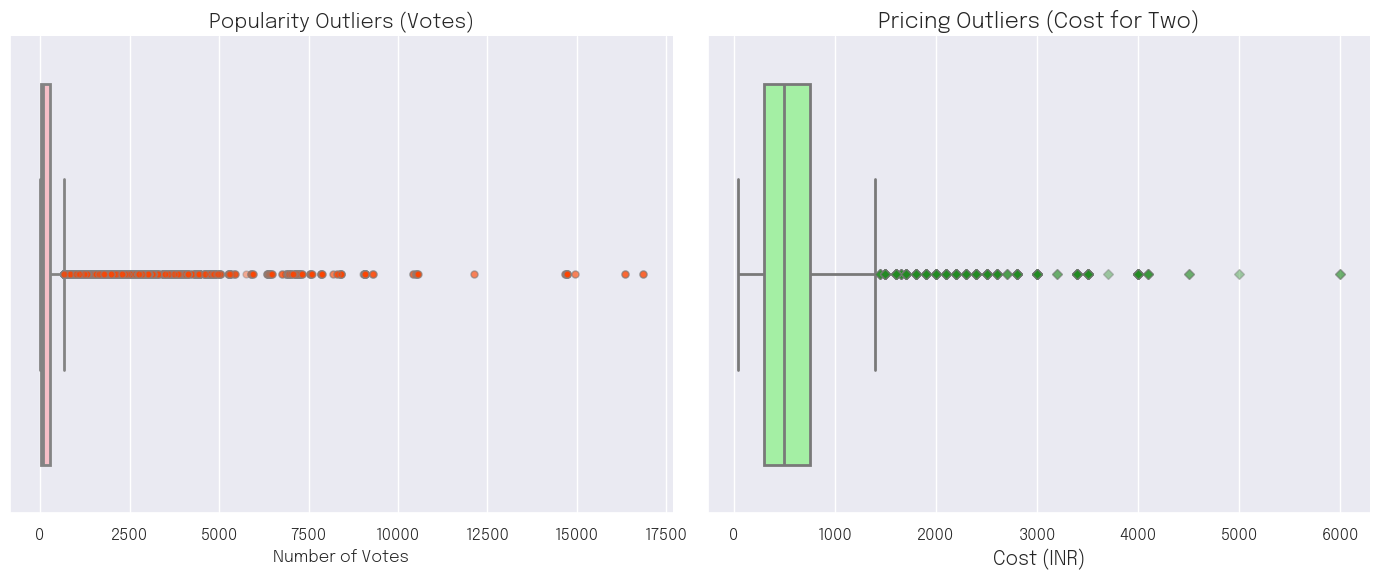

In [47]:
plt.rcParams['font.family'] = 'Epilogue'
#Percentiles and outliers Detection
vote_99th = np.percentile(df['votes'], 99)
print(f"99th Percentile of Votes: {vote_99th:.0f} (Anything above is extreme)")

cost_99th = np.percentile(df['cost_for_two'], 99)
print(f"99th Percentile of Cost for Two: ₹{cost_99th:.0f} (Anything above is extreme)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot 1: Votes
sns.boxplot(
    data=df, x='votes', ax=axes[0], 
    color='#FFB6C1',
    flierprops={'marker': 'o', 'markerfacecolor': '#FF4500', 'alpha': 0.4, 'markersize': 5},
    linewidth=2
)
axes[0].set_title('Popularity Outliers (Votes)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Number of Votes', fontsize=12, fontweight='bold')

# Boxplot 2: Cost
sns.boxplot(
    data=df, x='cost_for_two', ax=axes[1], 
    color='#98FB98',
    flierprops={'marker': 'D', 'markerfacecolor': '#228B22', 'alpha': 0.4, 'markersize': 5},
    linewidth=2
)
axes[1].set_title('Pricing Outliers (Cost for Two)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Cost (INR)', fontsize=14, fontweight='bold')

sns.despine(left=True)
plt.tight_layout()
sns.despine()
plt.tight_layout()
file_name = 'Outliers_Analysis' + '.png'
save_path = os.path.join(fig_dir, file_name)
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
print(f"✅ Figure saved successfully to: {save_path}")
plt.show()

##### Section 7.4: Restaurant Density (Appendix)

✅ Figure saved successfully to: d:\Spring Sem 26\Programming with Python\Final\Project_Final\Figures\Restaurant_Density_Top_12_Culinary_Hubs.png


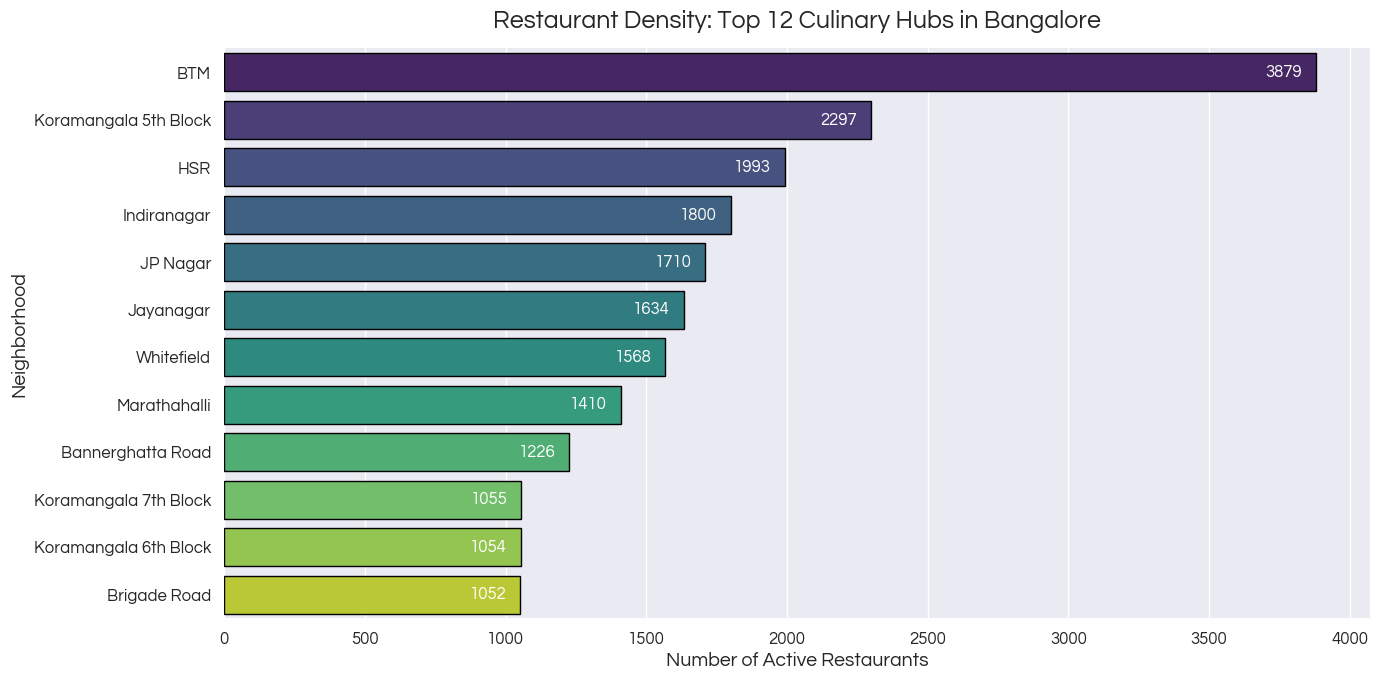

In [45]:
plt.rcParams['font.family'] = 'Questrial'
plt.figure(figsize=(14, 7))

# Get top locations
top_locations = df['location'].value_counts().head(12).reset_index()
top_locations.columns = ['Neighborhood', 'Restaurant Count']

ax = sns.barplot(
    data=top_locations, 
    x='Restaurant Count', 
    y='Neighborhood',
    hue='Neighborhood',   
    legend=False,         
    palette='viridis', 
    edgecolor='black',
    linewidth=1
)

plt.title('Restaurant Density: Top 12 Culinary Hubs in Bangalore', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Number of Active Restaurants', fontsize=14, fontweight='bold')
plt.ylabel('Neighborhood', fontsize=14, fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", 
                (p.get_width() - 50, p.get_y() + p.get_height() / 2.), 
                ha='right', va='center', 
                fontsize=12, fontweight='bold', color='white')

sns.despine(left=True, bottom=True)
plt.tight_layout()
file_name = 'Restaurant_Density_Top_12_Culinary_Hubs' + '.png'
save_path = os.path.join(fig_dir, file_name)
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
print(f"✅ Figure saved successfully to: {save_path}")
plt.show()